Rema-Kalenga boundary features: 1
Rema-Kalenga sites features: 59
Available fields: ['XCoord', 'ClusterID', 'OBJECTID_1', 'FREQUENCY', 'MEAN_PAR_L', 'ClusterID_', 'MEAN_GAP_F', 'system:index', 'YCoord']
{'ClusterID': 5, 'MEAN_PAR_L': 0.33117018625, 'XCoord': 91.62458, 'YCoord': 24.11235}
{'ClusterID': 27, 'MEAN_PAR_L': 3.94414734825, 'XCoord': 91.6306, 'YCoord': 24.165805}
{'ClusterID': 35, 'MEAN_PAR_L': 2.494383216, 'XCoord': 91.6436025, 'YCoord': 24.1705425}
{'ClusterID': 51, 'MEAN_PAR_L': 3.0017175675, 'XCoord': 91.6253075, 'YCoord': 24.2033275}
{'ClusterID': 3, 'MEAN_PAR_L': 2.8599865912, 'XCoord': 91.632832, 'YCoord': 24.109208}
{'ClusterID': 4, 'MEAN_PAR_L': 2.0680925488, 'XCoord': 91.626706, 'YCoord': 24.110476}
{'ClusterID': 7, 'MEAN_PAR_L': 3.1344433786, 'XCoord': 91.629136, 'YCoord': 24.113164}
{'ClusterID': 8, 'MEAN_PAR_L': 2.1191831826, 'XCoord': 91.630112, 'YCoord': 24.114924}
{'ClusterID': 9, 'MEAN_PAR_L': 3.2432822702, 'XCoord': 91.631906, 'YCoord': 24.116332}
{'ClusterI

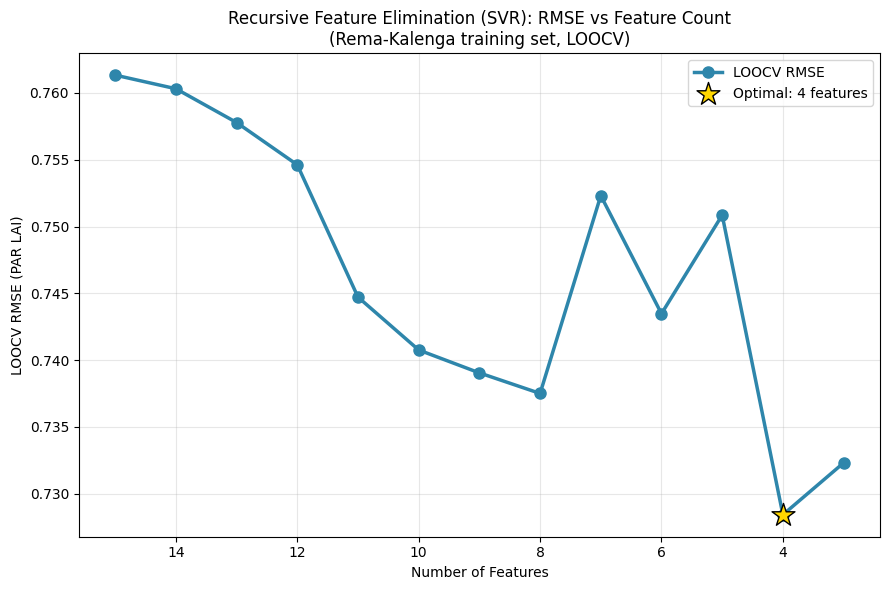

=== Rema-Kalenga SVR model performance summary (RFE-selected features) ===
                                              Set  N    R2  RMSE   MAE  rRMSE (%)  Bias (mean residual)
Rema-Kalenga Train (in-sample, SVR, RFE features) 47 0.357 0.705 0.537       32.6                -0.039
  Rema-Kalenga Test (held-out, SVR, RFE features) 12 0.057 0.869 0.661       40.1                -0.212

=== Feature importance proxy (|coefficient|, linear kernel only, RFE features) ===
Feature  Abs_Coefficient
    B11         0.222268
  GNDVI         0.137400
     B8         0.117550
    EVI         0.090915

=== Per-plot residuals (Rema-Kalenga test set, SVR, RFE features) ===
 cluster_id  observed_par_lai  predicted_par_lai  residual
          5          0.331170              2.088     1.757
          4          2.068093              2.258     0.190
         42          1.949388              1.809    -0.141
         14          1.625104              2.021     0.396
         56          3.173609         

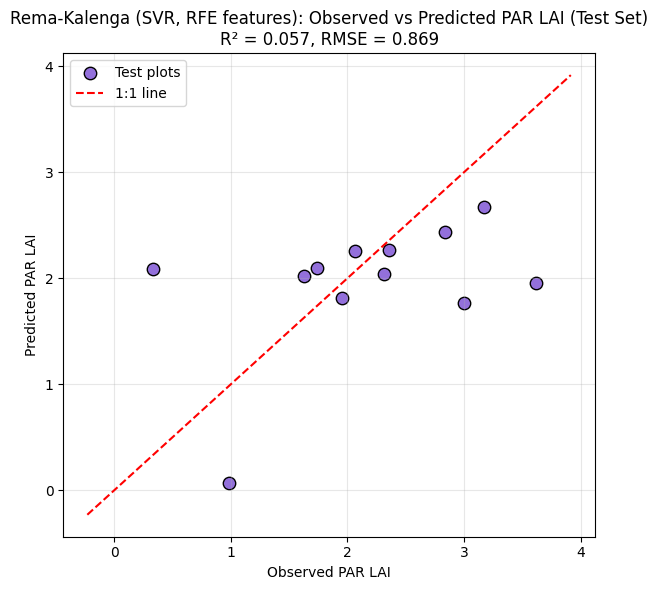

KNP boundary features: 1
KNP sites features: 40
Cleaned feature count: 40
Sample feature: {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [91.94278, 24.95203]}, 'id': '0000000000000000000c', 'properties': {'cluster_id': '20', 'latitude': 24.95203, 'longitude': 91.94278, 'par_lai': 1.6706171335}}
Sample square geometry (KNP): {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[91.94270594703491, 24.951963907026418], [91.94285098397934, 24.951963907026418], [91.94285098397934, 24.952097491494666], [91.94270594703491, 24.952097491494666], [91.94270594703491, 24.951963907026418]]]}
Number of available Sentinel-2 scenes (Jan-Mar 2022, KNP): 11
2022-01-01  —  cloud cover: 10.0%
2022-01-06  —  cloud cover: 19.3%
2022-01-26  —  cloud cover: 19.8%
2022-01-31  —  cloud cover: 1.5%
2022-02-15  —  cloud cover: 0.0%
2022-02-20  —  cloud cover: 3.5%
2022-03-02  —  cloud cover: 0.0%
2022-03-07  —  cloud cover: 0.0%
2022-03-12  —  cloud cover: 23.7%
2022-03-17  —  cloud cover: 0.

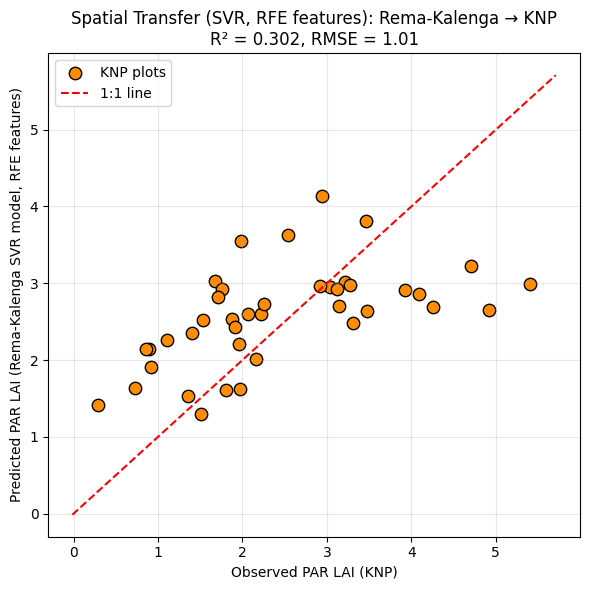

KNP export task started. Task ID: NBJHFAQTJVZBS2IRS2MSJNPV
Rema-Kalenga export task started. Task ID: 5D7UQ63NB7RLESVQYD6UVYXN
KNP task status: READY
Rema-Kalenga task status: READY


In [1]:
"""
LAI Estimation Pipeline — Support Vector Regression (SVR), with Recursive
Feature Elimination (RFE)
Source domain: Rema-Kalenga Wildlife Sanctuary
Spatial transfer target: Khadimnagar National Park (KNP)

RFE is applied AFTER hyperparameter tuning, using the tuned SVR as the
evaluator. Because SVR has no native feature_importances_ / coefficients for
non-linear kernels, elimination uses permutation_importance (works regardless
of kernel choice) computed on the training set only.

RFE runs via LOOCV on the 32-plot Rema-Kalenga TRAINING SET ONLY — the 8-plot
held-out test set and the KNP spatial-transfer target are never touched during
feature selection, avoiding data leakage.

From the RFE step onward, rfe_selected_features_svr (not the full 15-feature
feature_cols) is used for the final model fit, test evaluation, and transfer.

IMPORTANT: SVR is sensitive to feature scale. A StandardScaler is fit on the
training data only (on the RFE-selected columns, at final-fit time) and reused
for the test set and the KNP transfer target, to avoid data leakage.
"""

# ============================================================
# SETUP
# ============================================================
get_ipython().system('pip install earthengine-api geemap -q')

import ee
ee.Authenticate()
ee.Initialize(project='osmgee')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import itertools
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


# ============================================================
# REMA-KALENGA: BOUNDARY AND SITE LOCATIONS (SOURCE / TRAINING DATA)
# ============================================================
rema_boundary = ee.FeatureCollection('projects/osmgee/assets/RemaKalenga')
rema_sites = ee.FeatureCollection('projects/osmgee/assets/RemaSites')

print('Rema-Kalenga boundary features:', rema_boundary.size().getInfo())
print('Rema-Kalenga sites features:', rema_sites.size().getInfo())

rema_first_feature = rema_sites.first()
print('Available fields:', rema_first_feature.propertyNames().getInfo())

rema_sites_info = rema_sites.select(
    ['ClusterID', 'MEAN_PAR_L', 'XCoord', 'YCoord', 'longitude', 'Llllllatit']
).getInfo()

for f in rema_sites_info['features']:
    print(f['properties'])


# ============================================================
# CLEAN FIELD NAMES (XCoord/Llllllatit = longitude, YCoord/longitude = latitude)
# ============================================================
def clean_feature_rema(f):
    lon = ee.Number(f.get('XCoord'))
    lat = ee.Number(f.get('YCoord'))
    par_lai = ee.Number(f.get('MEAN_PAR_L'))
    cluster_id = f.get('ClusterID')

    return ee.Feature(
        ee.Geometry.Point([lon, lat]),
        {
            'cluster_id': cluster_id,
            'par_lai': par_lai,
            'longitude': lon,
            'latitude': lat
        }
    )

rema_sites_clean = rema_sites.map(clean_feature_rema)

print('Cleaned feature count:', rema_sites_clean.size().getInfo())
print('Sample feature:', rema_sites_clean.first().getInfo())


# ============================================================
# SENTINEL-2: LOAD AND FILTER FOR REMA-KALENGA FIELD WINDOW
# ============================================================
rema_field_start = ee.Date('2021-01-01')
rema_field_end = ee.Date('2021-03-31')

rema_s2_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(rema_boundary) \
    .filterDate(rema_field_start, rema_field_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))

print('Number of available Sentinel-2 scenes (Rema-Kalenga):', rema_s2_collection.size().getInfo())

rema_image_list = rema_s2_collection.toList(rema_s2_collection.size())
n_rema = rema_s2_collection.size().getInfo()
for i in range(n_rema):
    img = ee.Image(rema_image_list.get(i))
    date = img.date().format('YYYY-MM-dd').getInfo()
    cloud = img.get('CLOUDY_PIXEL_PERCENTAGE').getInfo()
    print(f'{date}  —  cloud cover: {cloud:.1f}%')


# ============================================================
# CLOUD MASK, COMPOSITE, AND SPECTRAL INDICES
# ============================================================
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    return image.updateMask(mask).divide(10000).copyProperties(image, image.propertyNames())

rema_s2_masked = rema_s2_collection.map(mask_s2_clouds)
rema_s2_composite = rema_s2_masked.median().clip(rema_boundary)

def add_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    gndvi = image.normalizedDifference(['B8', 'B3']).rename('GNDVI')

    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }).rename('EVI')

    savi = image.expression(
        '((NIR - RED) / (NIR + RED + 0.5)) * 1.5', {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('SAVI')

    msavi = image.expression(
        '(2 * NIR + 1 - sqrt((2 * NIR + 1)**2 - 8 * (NIR - RED))) / 2', {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('MSAVI')

    return image.addBands([ndvi, gndvi, evi, savi, msavi])

rema_s2_with_indices = add_indices(rema_s2_composite)

raw_bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
index_bands = ['NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']

final_image_rema = rema_s2_with_indices.select(raw_bands + index_bands)
print('Bands in Rema-Kalenga composite:', final_image_rema.bandNames().getInfo())


# ============================================================
# BUILD 15m x 15m SQUARE PLOTS AND EXTRACT MEAN SPECTRAL VALUES
# ============================================================
def make_square_plot(feature):
    point = feature.geometry()
    half_side = 7.5
    square = point.buffer(half_side, 1).bounds()
    return feature.setGeometry(square)

rema_sites_squares = rema_sites_clean.map(make_square_plot)
sample_geom = rema_sites_squares.first().geometry().getInfo()
print('Sample square plot geometry (Rema-Kalenga):', sample_geom)

rema_extracted = final_image_rema.reduceRegions(
    collection=rema_sites_squares,
    reducer=ee.Reducer.mean(),
    scale=10
)

rema_extracted_info = rema_extracted.getInfo()

for f in rema_extracted_info['features'][:5]:
    print(f['properties'])
    print('---')

rema_rows = [f['properties'] for f in rema_extracted_info['features']]
df_rema = pd.DataFrame(rema_rows)

id_cols = ['cluster_id', 'par_lai', 'longitude', 'latitude']
other_cols = [c for c in df_rema.columns if c not in id_cols]
df_rema = df_rema[id_cols + other_cols]
df_rema


# ============================================================
# TRAIN / TEST SPLIT (80/20 -> 32/8)
# ============================================================
feature_cols = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12',
                 'NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']
target_col = 'par_lai'

X_rema = df_rema[feature_cols]
y_rema = df_rema[target_col]

X_train_rema, X_test_rema, y_train_rema, y_test_rema = train_test_split(
    X_rema, y_rema, test_size=0.2, random_state=42
)

print('Train PAR LAI range:', round(y_train_rema.min(), 2), '-', round(y_train_rema.max(), 2))
print('Test PAR LAI range:', round(y_test_rema.min(), 2), '-', round(y_test_rema.max(), 2))
print('Train PAR LAI mean:', round(y_train_rema.mean(), 2))
print('Test PAR LAI mean:', round(y_test_rema.mean(), 2))


# ============================================================
# FEATURE SCALING (required for SVR — fit on FULL 15-feature train set here,
# used only for the hyperparameter search and RFE stages below; the scaler is
# refit on the RFE-selected columns at final-fit time, see that section)
# ============================================================
scaler_full = StandardScaler()
X_train_rema_scaled = pd.DataFrame(
    scaler_full.fit_transform(X_train_rema), columns=feature_cols, index=X_train_rema.index
)

print('Feature scaling applied (StandardScaler fit on 32 training plots only).')
print('Scaled train feature means (should be ~0):')
print(X_train_rema_scaled.mean().round(3))


# ============================================================
# SVR — HYPERPARAMETER SEARCH VIA LOOCV
# ============================================================
svr_param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.05, 0.1, 0.2],
    'gamma': ['scale', 'auto']
}

svr_keys = list(svr_param_grid.keys())
svr_combinations = list(itertools.product(*svr_param_grid.values()))
print(f'Total SVR hyperparameter combinations to test: {len(svr_combinations)}')

loo = LeaveOneOut()
svr_results = []

for combo in svr_combinations:
    params = dict(zip(svr_keys, combo))
    if params['kernel'] == 'linear' and params['gamma'] == 'auto':
        continue
    model = SVR(**params)

    scores = cross_val_score(model, X_train_rema_scaled, y_train_rema, cv=loo, scoring='neg_mean_squared_error')
    mean_mse = -scores.mean()
    rmse = np.sqrt(mean_mse)

    svr_results.append({**params, 'loocv_rmse': rmse})

svr_results_df = pd.DataFrame(svr_results).sort_values('loocv_rmse').reset_index(drop=True)
print('Top 5 SVR hyperparameter combinations by LOOCV RMSE:')
print(svr_results_df.head(5))


# ============================================================
# EXTRACT BEST HYPERPARAMETERS
# ============================================================
best_params_svr = svr_results_df.iloc[0][svr_keys].to_dict()
best_params_svr['C'] = float(best_params_svr['C'])
best_params_svr['epsilon'] = float(best_params_svr['epsilon'])

print('Best hyperparameters selected via LOOCV (SVR, Rema-Kalenga):')
print(best_params_svr)


def compute_metrics(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    rrmse = (rmse / y_true.mean()) * 100
    bias = (y_pred - y_true).mean()
    return {
        'Set': label,
        'N': len(y_true),
        'R2': round(r2, 3),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'rRMSE (%)': round(rrmse, 1),
        'Bias (mean residual)': round(bias, 3)
    }


# ============================================================
# RECURSIVE FEATURE ELIMINATION (RFE) — SVR
# Runs AFTER hyperparameter tuning, using the tuned SVR as the evaluator.
# SVR has no native feature_importances_/coef_ for non-linear kernels, so
# elimination is driven by permutation_importance (scored by RMSE increase
# when a feature is shuffled), which works for any kernel choice.
# Operates ONLY on the 32-plot training set via LOOCV/permutation on training
# data — the 8-plot test set and the KNP spatial-transfer target are never
# touched here.
# ============================================================
min_features = 3                 # safety floor given only 32 training samples
elimination_step = 1              # remove 1 feature per iteration
absolute_drop_threshold = 0.15    # stop if LOOCV RMSE rises by more than this (LAI units)

current_features_svr = feature_cols.copy()
rfe_results_svr = []
iteration = 0

print('\n' + '='*60)
print('STARTING RFE — SVR (Rema-Kalenga training set, LOOCV)')
print('='*60)

start_time = time.time()

while True:
    iteration += 1
    n_current = len(current_features_svr)

    # Re-scale using only the current feature subset (scaling depends on which
    # columns are present)
    scaler_iter = StandardScaler()
    X_train_iter_scaled = scaler_iter.fit_transform(X_train_rema[current_features_svr])

    svr_eval = SVR(**best_params_svr)
    scores = cross_val_score(
        svr_eval,
        X_train_iter_scaled,
        y_train_rema,
        cv=loo,
        scoring='neg_mean_squared_error'
    )
    rmse = np.sqrt(-scores.mean())

    if len(rfe_results_svr) == 0:
        baseline_rmse = rmse
        rmse_increase = 0.0
    else:
        baseline_rmse = rfe_results_svr[0]['rmse']
        rmse_increase = rmse - baseline_rmse

    print(f'\nIteration {iteration}: {n_current} features -> LOOCV RMSE = {rmse:.3f} '
          f'(change from baseline: {rmse_increase:+.3f})')

    rfe_results_svr.append({
        'iteration': iteration,
        'n_features': n_current,
        'features': current_features_svr.copy(),
        'rmse': rmse,
        'rmse_increase': rmse_increase
    })

    should_stop = False
    if len(rfe_results_svr) > 1 and rmse_increase > absolute_drop_threshold:
        should_stop = True
        print(f'  STOPPING: RMSE rose by {rmse_increase:.3f} (threshold: {absolute_drop_threshold})')
    if n_current <= min_features:
        should_stop = True
        print(f'  STOPPING: reached minimum feature count ({min_features})')

    if should_stop:
        break

    # Fit on full training subset, then compute permutation importance to rank features
    svr_importance = SVR(**best_params_svr)
    svr_importance.fit(X_train_iter_scaled, y_train_rema)

    perm_result = permutation_importance(
        svr_importance, X_train_iter_scaled, y_train_rema,
        n_repeats=30, random_state=42, scoring='neg_mean_squared_error'
    )
    importances = dict(zip(current_features_svr, perm_result.importances_mean))

    sorted_feats = sorted(importances.items(), key=lambda x: x[1])
    n_to_remove = min(elimination_step, len(current_features_svr) - min_features)
    features_to_remove = [f for f, _ in sorted_feats[:n_to_remove]]
    print(f'  Removing: {features_to_remove}')

    current_features_svr = [f for f in current_features_svr if f not in features_to_remove]

total_time = time.time() - start_time

best_rfe_svr = min(rfe_results_svr, key=lambda x: x['rmse'])
rfe_selected_features_svr = best_rfe_svr['features']

print('\n' + '='*60)
print('RFE COMPLETE — SVR')
print('='*60)
print(f'Total time: {total_time/60:.1f} min')
print(f'Optimal feature count: {best_rfe_svr["n_features"]}')
print(f'Optimal features: {rfe_selected_features_svr}')
print(f'Optimal LOOCV RMSE: {best_rfe_svr["rmse"]:.3f} (baseline was {rfe_results_svr[0]["rmse"]:.3f})')

# --- Plot: LOOCV RMSE vs number of features ---
rfe_df_svr = pd.DataFrame(rfe_results_svr)

plt.figure(figsize=(9, 6))
plt.plot(rfe_df_svr['n_features'], rfe_df_svr['rmse'], marker='o', markersize=8,
         linewidth=2.5, color='#2E86AB', label='LOOCV RMSE')

best_idx_svr = rfe_df_svr['rmse'].idxmin()
plt.scatter(rfe_df_svr.loc[best_idx_svr, 'n_features'], rfe_df_svr.loc[best_idx_svr, 'rmse'],
            color='gold', s=300, marker='*', zorder=5, edgecolor='black',
            label=f'Optimal: {rfe_df_svr.loc[best_idx_svr, "n_features"]} features')

plt.xlabel('Number of Features')
plt.ylabel('LOOCV RMSE (PAR LAI)')
plt.title('Recursive Feature Elimination (SVR): RMSE vs Feature Count\n(Rema-Kalenga training set, LOOCV)')
plt.gca().invert_xaxis()
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# REFIT FINAL MODEL ON RFE-SELECTED FEATURES — THIS IS THE MODEL USED FOR TRANSFER
# A fresh scaler is fit on the RFE-selected columns only (train set), and
# reused (never refit) for the test set and the KNP transfer target.
# ============================================================
scaler = StandardScaler()
X_train_rema_final_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_rema[rfe_selected_features_svr]),
    columns=rfe_selected_features_svr, index=X_train_rema.index
)
X_test_rema_final_scaled = pd.DataFrame(
    scaler.transform(X_test_rema[rfe_selected_features_svr]),
    columns=rfe_selected_features_svr, index=X_test_rema.index
)

final_svr_rema = SVR(**best_params_svr)
final_svr_rema.fit(X_train_rema_final_scaled, y_train_rema)

y_pred_train_rema_svr = final_svr_rema.predict(X_train_rema_final_scaled)
y_pred_test_rema_svr = final_svr_rema.predict(X_test_rema_final_scaled)

metrics_train_rema_svr = compute_metrics(y_train_rema, y_pred_train_rema_svr, 'Rema-Kalenga Train (in-sample, SVR, RFE features)')
metrics_test_rema_svr = compute_metrics(y_test_rema, y_pred_test_rema_svr, 'Rema-Kalenga Test (held-out, SVR, RFE features)')

metrics_df_rema_svr = pd.DataFrame([metrics_train_rema_svr, metrics_test_rema_svr])
print('=== Rema-Kalenga SVR model performance summary (RFE-selected features) ===')
print(metrics_df_rema_svr.to_string(index=False))
print()

if best_params_svr['kernel'] == 'linear':
    importance_df_rema_svr = pd.DataFrame({
        'Feature': rfe_selected_features_svr,
        'Abs_Coefficient': np.abs(final_svr_rema.coef_[0])
    }).sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)
    print('=== Feature importance proxy (|coefficient|, linear kernel only, RFE features) ===')
    print(importance_df_rema_svr.to_string(index=False))
else:
    print('Selected kernel is non-linear (rbf) — SVR has no native feature importance.')
    print('(Permutation importance was used internally to drive RFE elimination.)')
print()

residuals_df_rema_svr = pd.DataFrame({
    'cluster_id': df_rema.loc[X_test_rema.index, 'cluster_id'].values,
    'observed_par_lai': y_test_rema.values,
    'predicted_par_lai': y_pred_test_rema_svr.round(3),
    'residual': (y_pred_test_rema_svr - y_test_rema.values).round(3)
})
print('=== Per-plot residuals (Rema-Kalenga test set, SVR, RFE features) ===')
print(residuals_df_rema_svr.to_string(index=False))
print()

plt.figure(figsize=(6, 6))
plt.scatter(y_test_rema, y_pred_test_rema_svr, color='mediumpurple', edgecolor='black', s=80, label='Test plots')
lims = [min(y_test_rema.min(), y_pred_test_rema_svr.min()) - 0.3,
        max(y_test_rema.max(), y_pred_test_rema_svr.max()) + 0.3]
plt.plot(lims, lims, 'r--', label='1:1 line')
plt.xlabel('Observed PAR LAI')
plt.ylabel('Predicted PAR LAI')
plt.title(f'Rema-Kalenga (SVR, RFE features): Observed vs Predicted PAR LAI (Test Set)\n'
          f'R² = {metrics_test_rema_svr["R2"]}, RMSE = {metrics_test_rema_svr["RMSE"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# NAIVE SPATIAL TRANSFER: KNP (TRANSFER TARGET)
# ============================================================
knp_boundary = ee.FeatureCollection('projects/osmgee/assets/KNP')
knp_sites = ee.FeatureCollection('projects/osmgee/assets/SitesLocation')

print('KNP boundary features:', knp_boundary.size().getInfo())
print('KNP sites features:', knp_sites.size().getInfo())

def clean_feature_knp(f):
    lon = ee.Number(f.get('XCoord'))
    lat = ee.Number(f.get('YCoord'))
    par_lai = ee.Number(f.get('MEAN_PAR_L'))
    cluster_id = f.get('ClusterID')

    return ee.Feature(
        ee.Geometry.Point([lon, lat]),
        {
            'cluster_id': cluster_id,
            'par_lai': par_lai,
            'longitude': lon,
            'latitude': lat
        }
    )

knp_sites_clean = knp_sites.map(clean_feature_knp)

print('Cleaned feature count:', knp_sites_clean.size().getInfo())
print('Sample feature:', knp_sites_clean.first().getInfo())

knp_sites_squares = knp_sites_clean.map(make_square_plot)
print('Sample square geometry (KNP):', knp_sites_squares.first().geometry().getInfo())

# KNP field campaign window (March 2022)
knp_apply_start = ee.Date('2022-01-01')
knp_apply_end = ee.Date('2022-03-31')

knp_s2_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(knp_boundary) \
    .filterDate(knp_apply_start, knp_apply_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))

print('Number of available Sentinel-2 scenes (Jan-Mar 2022, KNP):', knp_s2_collection.size().getInfo())

knp_image_list = knp_s2_collection.toList(knp_s2_collection.size())
n_knp = knp_s2_collection.size().getInfo()
for i in range(n_knp):
    img = ee.Image(knp_image_list.get(i))
    date = img.date().format('YYYY-MM-dd').getInfo()
    cloud = img.get('CLOUDY_PIXEL_PERCENTAGE').getInfo()
    print(f'{date}  —  cloud cover: {cloud:.1f}%')

knp_s2_masked = knp_s2_collection.map(mask_s2_clouds)
knp_s2_composite = knp_s2_masked.median().clip(knp_boundary)
knp_s2_with_indices = add_indices(knp_s2_composite)

final_image_knp = knp_s2_with_indices.select(raw_bands + index_bands)
print('Bands in KNP composite:', final_image_knp.bandNames().getInfo())

knp_extracted = final_image_knp.reduceRegions(
    collection=knp_sites_squares,
    reducer=ee.Reducer.mean(),
    scale=10
)

knp_extracted_info = knp_extracted.getInfo()
knp_rows = [f['properties'] for f in knp_extracted_info['features']]
df_knp = pd.DataFrame(knp_rows)

other_cols = [c for c in df_knp.columns if c not in id_cols]
df_knp = df_knp[id_cols + other_cols]

print(f'Extracted {len(df_knp)} plots')
df_knp


# ============================================================
# APPLY FROZEN SVR MODEL TO KNP (NO RETRAINING) — RFE-SELECTED FEATURES ONLY
# IMPORTANT: use the SAME scaler fit on Rema-Kalenga training data (RFE
# features) — never refit the scaler on KNP data, or this stops being a true
# naive transfer test.
# ============================================================
X_knp = df_knp[rfe_selected_features_svr]
X_knp_scaled = pd.DataFrame(
    scaler.transform(X_knp), columns=rfe_selected_features_svr, index=X_knp.index
)
y_knp_true = df_knp['par_lai']

y_knp_pred_svr = final_svr_rema.predict(X_knp_scaled)

metrics_transfer_knp_svr = compute_metrics(
    y_knp_true, y_knp_pred_svr, 'Spatial Transfer: Rema-Kalenga SVR model (RFE features) -> KNP (40 plots)'
)
transfer_metrics_df_knp_svr = pd.DataFrame([metrics_transfer_knp_svr])

print('=== Spatial Transfer Performance (Rema-Kalenga SVR -> KNP, RFE features) ===')
print(transfer_metrics_df_knp_svr.to_string(index=False))
print()

transfer_residuals_df_knp_svr = pd.DataFrame({
    'cluster_id': df_knp['cluster_id'],
    'observed_par_lai': y_knp_true.round(3),
    'predicted_par_lai': y_knp_pred_svr.round(3),
    'residual': (y_knp_pred_svr - y_knp_true).round(3)
})
print('=== Per-plot residuals (KNP, spatial transfer, SVR, RFE features) ===')
print(transfer_residuals_df_knp_svr.to_string(index=False))
print()

plt.figure(figsize=(6, 6))
plt.scatter(y_knp_true, y_knp_pred_svr, color='darkorange', edgecolor='black', s=80, label='KNP plots')
lims = [min(y_knp_true.min(), y_knp_pred_svr.min()) - 0.3,
        max(y_knp_true.max(), y_knp_pred_svr.max()) + 0.3]
plt.plot(lims, lims, 'r--', label='1:1 line')
plt.xlabel('Observed PAR LAI (KNP)')
plt.ylabel('Predicted PAR LAI (Rema-Kalenga SVR model, RFE features)')
plt.title(f'Spatial Transfer (SVR, RFE features): Rema-Kalenga → KNP\n'
          f'R² = {metrics_transfer_knp_svr["R2"]}, RMSE = {metrics_transfer_knp_svr["RMSE"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# EXPORT COMPOSITES TO GOOGLE DRIVE (for later full-map prediction)
# ============================================================
export_task_knp_svr = ee.batch.Export.image.toDrive(
    image=final_image_knp,
    description='KNP_LAI_features_export_svr',
    folder='GEE_exports',
    fileNamePrefix='KNP_features_2022_JanMar',
    region=knp_boundary.geometry(),
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task_knp_svr.start()
print('KNP export task started. Task ID:', export_task_knp_svr.id)

export_task_rema_svr = ee.batch.Export.image.toDrive(
    image=final_image_rema,
    description='RemaKalenga_LAI_features_export_svr',
    folder='GEE_exports',
    fileNamePrefix='RemaKalenga_features',
    region=rema_boundary.geometry(),
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task_rema_svr.start()
print('Rema-Kalenga export task started. Task ID:', export_task_rema_svr.id)

print('KNP task status:', export_task_knp_svr.status()['state'])
print('Rema-Kalenga task status:', export_task_rema_svr.status()['state'])